<a href="https://colab.research.google.com/github/Pentaphone/nn_tests/blob/main/nn_test2/nn_test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup

In [42]:
# installs, imports
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2 as transforms

!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("markinsuff/lipophilicity") + "/Lipophilicity.csv"
print("Path to dataset:", path)
print()

!pip install rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw


# config
batch_size = 64


# data
class LipophilicityDataset(torch.utils.data.Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
      if torch.is_tensor(i):
        i = i.tolist()

      smiles = self.data.loc[i, "RDKIT_SMILES"]
      exp = self.data.loc[i, "exp"]

      return (smiles, exp)

dataset = LipophilicityDataset(path)

training_data, test_data = torch.utils.data.random_split(dataset, [0.8, 0.2])

training_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)


Using Colab cache for faster access to the 'lipophilicity' dataset.
Path to dataset: /kaggle/input/lipophilicity/Lipophilicity.csv



### Examples

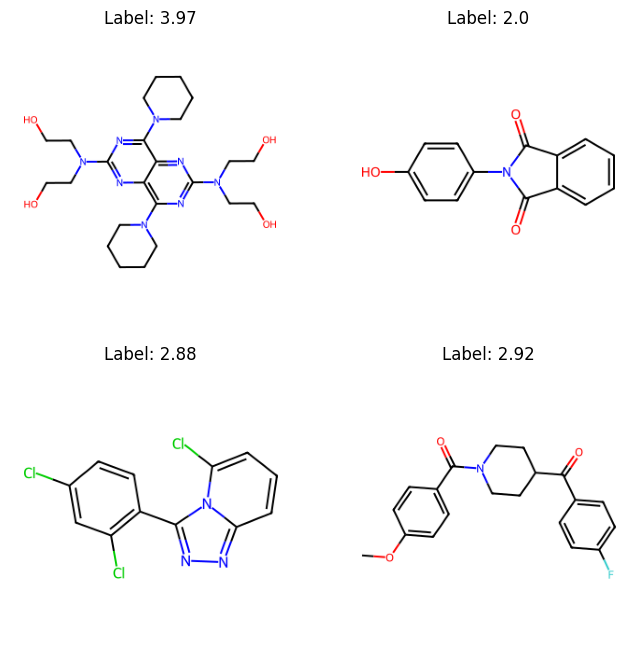

In [50]:
# examples
plt.figure(figsize=(8, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    rand_index = torch.randint(0, len(training_data)-16, (1,)).item()
    smiles, label = training_data[rand_index]
    mol = Chem.MolFromSmiles(smiles)
    image = Draw.MolToImage(mol)
    plt.imshow(image)
    plt.title(f"Label: {label}")
    plt.axis("off")